## **[기말평가] 주요 대학별 2026학년도 정시 실시간 지원현황 데이터 분석**
> 포함할 주요 대학 : **부천대학교, 유한대학교, 연성대학교, 대림대학교, 동서울대학교, 동양미래대학교**\
> 주요 대학의 실시간 지원현황 중에 '**정원내 일반전형 수능 경쟁률 현황**'과 관련된(학과별 경쟁률 데이터가 포함된) \<table> 자료만 사용

In [16]:
## [부천대학교] URL로 2026학년도 정시 실시간 지원현황 웹 페이지 열어보기
import webbrowser as wb

url = 'https://ratio.uwayapply.com/Sl5KTEJKQ0NhTEotZlRm'
wb.open_new(url)  #브라우저에 사이트가 열림

True

----

### **[문제] 타 대학 컴퓨터소프트웨어 관련 학과와의 입시 경쟁률 비교 분석하기**
##### [요구사항] 1~10까지의 각 단계에 대한 결과를 명확히 하여 제출하시오.
#### **1. [사전 작업] 대학별 스크랩핑할 페이지 정보를 데이터 프레임으로 만들기: df_url**
##### > 대학명, 페이지 url, 페이지 내 추출할 \<table> index 번호, 추출할 컬럼 index, **비교할 대학의 학과명** 으로 구성
> 포함할 주요 대학 (SW 관련 학과명)\
> 부천대학교(컴퓨터소프트웨어과), 유한대학교(컴퓨터소프트웨어전공), 연성대학교(컴퓨터소프트웨어과),\
> 대림대학교(소프트웨어학부), 동서울대학교(컴퓨터소프트웨어학과), 동양미래대학교(컴퓨터소프트웨어공학과)
##### > 각 대학별 추출할 index 값은 '정원내일반전형 수능' 테이블의 순서 번호를 반영하여 수정
#### **2. [사전 작업] 각 대학의 \<table> 데이터를 수집해주는 함수 만들기: get_table()**
##### > 수집 함수에 수집할 대학의 url과 \<table> index 값을 넘겨서 호출함.
##### > 수집 함수는 url에 해당하는 페이지에서 index에 해당하는 \<table> 값만으로 데이터 프레임을 구성해 반환
#### **3. [데이터 구축] 주요 대학의 지원현황 데이터 프레임 구축하기: df_all**
##### 앞에서 구축한 df_url을 활용: 각 대학별 Table scripting을 하여 분석용 데이터 df_all에 통합
##### (1) 대학별 데이터 추출
##### 앞의 2.번 문항에서 생성한 수집 함수를 호출하여 해결
##### (2) 불필요 컬럼 제거: 필요한 컬럼만 선택
##### (3) 컬럼 통일
##### 통일할 컬럼명(new_cols)은 ['전형', '모집인원', '지원인원', '경쟁률']
##### (4) '대학' 컬럼 추가
##### 컬럼 값은 해당 대학명 사용
##### (5) 전체 데이터 프레임에 통합: df_all
##### 통합된 데이터 프레임 정보를 확인: Ipsi_202603_all.xlsx
#### **4. [데이터 구축] 추출된 데이터에 대한 정제하기 : 데이터 후반 작업**
##### > 컬럼 순서 조정: ['대학', '모집단위', '모집인원', '지원인원', '경쟁률'] 순으로 조정
##### > 행 제거 : 모집단위가 학과명이 아닌 경우 > '모집단위'에 '소계', '총계' 등이 포함된 경우 행 제거
##### > 모집단위 값 정제 : 모집단위에서 학과명 이외는 버림
##### > '경쟁률' 컬럼 값 정제 : 경쟁률 숫자 이외는 버림
##### > '경쟁률' 컬럼 자료형 변경 : 지원율 데이터 타입을 float로 변경
#### **5. [데이터 구축] 구축된 지원현황 통합 데이터 프레임을 파일로 저장하기: Ipsi_202603_all.xlsx**
##### > .xlsx나 .csv 파일로 저장 : index는 빼고 저장
##### > 저장된 내용의 적절성 검토
#### **6. [분석-대학 전체] 대학별 합계 경쟁률 데이터 프레임 구축하기: df_tot**
##### > 대학별 총모집인원, 총지원인원, 경쟁률 컬럼으로 구성
#### **7. [분석-대학 전체] 대학별 비교 그래프 그리기**
##### > 대학별 합계 경쟁률 순위 막대 그래프 그리기
##### > 대학별 합계 지원자 수 순위 막대 그래프 그리기
##### > [부천대학교] 모집단위별 지원자 수 점유 그래프 그리기
#### **8. [분석-상하위학과] 대학별 경쟁률 상위 3, 하위 3개 학과 정보 추출하기: df_top3, df_bottom3**
##### > 각 대학별로 경쟁률 상위 3개 모집단위(학과)명, 경쟁률을 순서대로 출력
##### > 각 대학별로 경쟁률 하위 3개 모집단위(학과)명, 경쟁률을 순서대로 출력
##### > 각 대학별로 경쟁률 하위 3개 모집단위(학과)에 대한 막대그래프로 그리기
#### **9. [분석-SW관련학과] 비교 대상 소프트웨어 관련 학과만 데이터 추출하여 데이터 프레임 구축하기: df_sw**
> 부천대학교(컴퓨터소프트웨어과), 유한대학교(컴퓨터소프트웨어전공), 연성대학교(컴퓨터소프트웨어과),\
> 대림대학교(소프트웨어학부), 동서울대학교(컴퓨터소프트웨어학과), 동양미래대학교(컴퓨터소프트웨어공학과)
##### > 대학명, 비교할 대학의 학과명 만으로 데이터 프레임 구성
##### > 컬럼은 ['대학', '모집단위', '모집인원', '지원인원', '경쟁률']로 구성
#### **10. [분석-SW관련학과] 대학별 SW 관련 학과와 비교 그래프 그리기**
##### > 대학별 SW 관련 학과 경쟁률 순위 막대 그래프 그리기
##### >> 경쟁률이 높은 순으로 보기
##### > 대학별 SW 관련 학과 총 지원자 수 순위 막대 그래프 그리기
##### >> 총 지원자 수가 많은 순으로 보기

#### **0. 주요 대학의 2026학년도 정시 실시간 지원현황 페이지를 방문하여 페이지 정보 알아보기**
> 부천대학교: https://ratio.uwayapply.com/Sl5KTEJKQ0NhTEotZlRm \
> 유한대학교: https://ratio.uwayapply.com/Sl5KVzh8OmJKQ0NhTEotZlRm \
> 연성대학교: https://ratio.uwayapply.com/Sl5Kclc6JldhYGJKQ0NhTEotZlRm  \
> 대림대학교: https://ratio.uwayapply.com/Sl5KTSVDYDhWSkNDYUxKLWZUZg==  \
> 동서울대학교: https://ratio.uwayapply.com/Sl5KOlZKQ0NhTEotZlRm \
> 동양미래대학교: https://addon.jinhakapply.com/RatioV1/RatioH/Ratio40580401.html

#### **1. 추출할 페이지 정보 데이터 프레임 구축: df_url**
> 스크래핑할 각 대학의 대학명, 페이지 url, 추출할 \<table> index, 추출할 컬럼 index, SW관련학과명으로 구성\
> 각 대학별 추출할 index 값은 '정원내일반전형 수능' 테이블의 순서 번호를 반영하여 수정

In [17]:
##페이지 정보 데이터 프레임 구축: 대학명, url, index, sel_cols, SW관련학과
import pandas as pd

# 각 대학 페이지에서 '정원내일반전형 수능' 테이블 구조를 확인하여 index, sel_cols 설정
df_url = pd.DataFrame({
    'university': ['부천대학교', '유한대학교', '연성대학교', '대림대학교', '동서울대학교', '동양미래대학교'],
    'url': [
        'https://ratio.uwayapply.com/Sl5KTEJKQ0NhTEotZlRm',
        'https://ratio.uwayapply.com/Sl5KVzh8OmJKQ0NhTEotZlRm',
        'https://ratio.uwayapply.com/Sl5Kclc6JldhYGJKQ0NhTEotZlRm',
        'https://ratio.uwayapply.com/Sl5KTSVDYDhWSkNDYUxKLWZUZg==',
        'https://ratio.uwayapply.com/Sl5KOlZKQ0NhTEotZlRm',
        'https://addon.jinhakapply.com/RatioV1/RatioH/Ratio40580401.html'
    ],
    'index': [1, 1, 1, 2, 2, 1],
    'sel_cols': [[1,2,3,4], [0,1,2,3], [1,2,3,4], [1,2,3,4], [1,2,3,4], [0,1,2,3]],
    'deptname': ['컴퓨터소프트웨어과', '컴퓨터소프트웨어전공', '컴퓨터소프트웨어과',
                 '소프트웨어학부', '컴퓨터소프트웨어학과', '컴퓨터소프트웨어공학과']
})

df_url

,university,url,index,sel_cols,deptname
0,부천대학교,https://ratio.uwayapply.com/Sl5KTEJKQ0NhTEotZlRm,1,"[1, 2, 3, 4]",컴퓨터소프트웨어과
1,유한대학교,https://ratio.uwayapply.com/Sl5KVzh8OmJKQ0NhTE...,1,"[0, 1, 2, 3]",컴퓨터소프트웨어전공
2,연성대학교,https://ratio.uwayapply.com/Sl5Kclc6JldhYGJKQ0...,1,"[1, 2, 3, 4]",컴퓨터소프트웨어과
3,대림대학교,https://ratio.uwayapply.com/Sl5KTSVDYDhWSkNDYU...,2,"[1, 2, 3, 4]",소프트웨어학부
4,동서울대학교,https://ratio.uwayapply.com/Sl5KOlZKQ0NhTEotZlRm,2,"[1, 2, 3, 4]",컴퓨터소프트웨어학과
5,동양미래대학교,https://addon.jinhakapply.com/RatioV1/RatioH/R...,1,"[0, 1, 2, 3]",컴퓨터소프트웨어공학과


#### **2. [사전 작업] 각 대학의 \<table> 데이터를 수집해주는 함수 만들기: get_table()**
##### > 수집 함수에 수집할 대학의 url과 \<table> index 값과 header 정보를 넘겨서 호출함.
##### > 수집 함수는 url에 해당하는 페이지에서 index에 해당하는 \<table> 값만으로 데이터 프레임을 구성해 반환

##### **테이블 추출 함수 만들기**
> 수집 함수에 수집할 대학의 url과 \<table> index 값과 header 정보를 넘겨서 호출함.\
> 수집 함수는 url에 해당하는 페이지에서 index에 해당하는 \<table> 값만으로 데이터 프레임을 구성해 반환

In [18]:
## [함수 만들기] 경쟁률 현황을 데이터 프레임으로 구축하여 반환
import requests
import warnings

def get_table(url, index=0, header=None):
    warnings.filterwarnings('ignore')
    response = requests.get(url, headers=header, verify=False)
    response.encoding = response.apparent_encoding   # EUC-KR/UTF-8 자동 감지
    tables = pd.read_html(response.text)
    return tables[index]

##### **get_table() 함수 동작 확인**
> 부천대학교 페이지에서 테이블 데이터 추출로 확인

In [19]:
## [연습] 경쟁률 현황을 데이터 프레임으로 구축하기
import pandas as pd
import urllib3  

seq = 0  #대학 순서 변호: 변경해서 대학별 확인
url = df_url['url'][seq] 
header = { 'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3',
'Referer': url } 
index = df_url['index'][seq]
sel_cols = df_url['sel_cols'][seq]
# 웹 페이지에서 표 스크래핑
df_a = get_table(url, index, header)  #데이터 프레임
df_a = df_a.iloc[:, sel_cols]  #필요한 컬럼만 추출
df_a.head()

,모집단위,모집인원,지원인원,경쟁률
0,건축과(3년제),1,37,37.00 : 1
1,실내건축디자인학과(3년제),2,74,37.00 : 1
2,토목공학과,2,79,39.50 : 1
3,정보통신과,2,48,24.00 : 1
4,전자공학과 전자공학전공,2,97,48.50 : 1


#### **3. [데이터 구축] 주요 대학의 지원현황 데이터 프레임 구축하기**
##### 앞에서 구축한 df_url을 활용: 각 대학별 Table scripting을 하여 분석용 데이터 df_all에 통합
##### (1) 대학별 데이터 추출
##### 앞의 2.번 문항에서 생성한 수집 함수를 호출하여 해결
##### (2) 불필요 컬럼 제거: 필요한 컬럼만 선택
##### (3) 컬럼 통일
##### 통일할 컬럼명(new_cols)은 ['전형', '모집인원', '지원인원', '경쟁률']
##### (4) '대학' 컬럼 추가
##### 컬럼 값은 해당 대학명 사용
##### (5) 전체 데이터 프레임에 통합: df_all
##### 통합된 데이터 프레임 정보를 확인

##### **대학별 입시 경쟁률 데이터를 추출**
> 구축된 대학별 페이지 데이터 사용

In [20]:
## 대학별 입시 경쟁률 데이터를 추출하여 : 위에서 만든 함수와 제공함를 활용
## 불필요한 컬럼 제거 및 컬럼 통일 작업 후
## 하나의 데이터 프레임으로 통합
df = pd.DataFrame()      # 각 대학의 추출된 데이터 프레임 생성
df_all = pd.DataFrame()  # 하나로 통합할 데이터 프레임 생성
header = { 'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3',
'Referer': None }

## 각 대학의 지원 현황 페이지에 접근해서 데이터 추출 및 컬럼 통일 후 새 데이터 프레임에 통합 구축
new_cols = ['모집단위', '모집인원', '지원인원', '경쟁률']

for _, row in df_url.iloc[::-1].iterrows():
    header['Referer'] = row['url']
    df = get_table(row['url'], row['index'], header)
    df = df.iloc[:, row['sel_cols']]
    df.columns = new_cols
    df['대학'] = row['university']
    df_all = pd.concat([df_all, df])

## 통합된 데이터 프레임 확인
df_all

,모집단위,모집인원,지원인원,경쟁률,대학
0,기계공학과,11,251,22.82 : 1,동양미래대학교
1,기계설계공학과,11,197,17.91 : 1,동양미래대학교
2,자동화공학과(3년),6,126,21.00 : 1,동양미래대학교
3,로봇소프트웨어과(3년),7,122,17.43 : 1,동양미래대학교
4,전기공학과,11,289,26.27 : 1,동양미래대학교
...,...,...,...,...,...
30,치위생학과(3년제),2,79,39.50 : 1,부천대학교
31,응급구조학과(3년제),2,75,37.50 : 1,부천대학교
32,반려동물과,2,64,32.00 : 1,부천대학교
33,자율전공학과,1,48,48.00 : 1,부천대학교


##### **통합된 데이터를 파일로 저장Ipsi_202603_all.xlsx**

In [21]:
## 통합된 데이터를 파일로 저장
df_all.to_excel('Ipsi_202603_all.xlsx', index=False)

#### **4. [데이터 구축] 추출된 데이터에 대한 정제하기 : 데이터 후반 작업**
##### 컬럼 순서 조정: ['대학', '모집단위', '모집인원', '지원인원', '경쟁률'] 순으로 조정
##### 행 제거 : 모집단위가 학과명이 아닌 경우 > '모집단위'에 '소계', '총계' 등이 포함된 경우
> 모집단위 값 정제 : 모집단위에서 학과명 이외는 버림\
> '경쟁률' 컬럼 값 정제 : 경쟁률 숫자 이외는 버림
##### '경쟁률' 컬럼 자료형 변경 : 지원율 데이터 타입을 float로 변경

##### **컬럼 순서 변경**
> ['대학', '모집단위', '모집인원', '지원인원', '경쟁률'] 순으로 조정

In [22]:
#### > 컬럼 순서를 ['대학', '모집단위', '모집인원', '지원인원', '경쟁률'] 순으로 조정
df_all = df_all[['대학', '모집단위', '모집인원', '지원인원', '경쟁률']]

df_all

,대학,모집단위,모집인원,지원인원,경쟁률
0,동양미래대학교,기계공학과,11,251,22.82 : 1
1,동양미래대학교,기계설계공학과,11,197,17.91 : 1
2,동양미래대학교,자동화공학과(3년),6,126,21.00 : 1
3,동양미래대학교,로봇소프트웨어과(3년),7,122,17.43 : 1
4,동양미래대학교,전기공학과,11,289,26.27 : 1
...,...,...,...,...,...
30,부천대학교,치위생학과(3년제),2,79,39.50 : 1
31,부천대학교,응급구조학과(3년제),2,75,37.50 : 1
32,부천대학교,반려동물과,2,64,32.00 : 1
33,부천대학교,자율전공학과,1,48,48.00 : 1


##### **불필요한 제거**

In [23]:
## 행 제거 : 모집단위가 학과명이 아닌 경우 > '모집단위'에 '소계', '총계', '합계' 등이 포함된 경우
df_all = df_all[~df_all['모집단위'].str.contains('소계|총계|합계', na=False)]

df_all

,대학,모집단위,모집인원,지원인원,경쟁률
0,동양미래대학교,기계공학과,11,251,22.82 : 1
1,동양미래대학교,기계설계공학과,11,197,17.91 : 1
2,동양미래대학교,자동화공학과(3년),6,126,21.00 : 1
3,동양미래대학교,로봇소프트웨어과(3년),7,122,17.43 : 1
4,동양미래대학교,전기공학과,11,289,26.27 : 1
...,...,...,...,...,...
29,부천대학교,치기공과(3년제),1,49,49.00 : 1
30,부천대학교,치위생학과(3년제),2,79,39.50 : 1
31,부천대학교,응급구조학과(3년제),2,75,37.50 : 1
32,부천대학교,반려동물과,2,64,32.00 : 1


##### **모집단위 값 정제**
> 학과명 이외는 버림

In [24]:
## 모집단위 값 정제 : 모집단위에서 학과명 이외는 버림
## 1) 괄호 내용 제거 (예: 3년제, 주간, 야간)
## 2) ※ 이후 부가 설명 제거
## 3) '공백 + 전공명' 형태의 세부 전공 접미사 제거 (예: 뷰티케어과 헤어디자인전공 → 뷰티케어과)
df_all['모집단위'] = (df_all['모집단위']
    .str.replace(r'\(.*?\)', '', regex=True)
    .str.replace(r'\s*※.*', '', regex=True)
    .str.replace(r'\s+\S+전공$', '', regex=True)
    .str.strip()
)

df_all

,대학,모집단위,모집인원,지원인원,경쟁률
0,동양미래대학교,기계공학과,11,251,22.82 : 1
1,동양미래대학교,기계설계공학과,11,197,17.91 : 1
2,동양미래대학교,자동화공학과,6,126,21.00 : 1
3,동양미래대학교,로봇소프트웨어과,7,122,17.43 : 1
4,동양미래대학교,전기공학과,11,289,26.27 : 1
...,...,...,...,...,...
29,부천대학교,치기공과,1,49,49.00 : 1
30,부천대학교,치위생학과,2,79,39.50 : 1
31,부천대학교,응급구조학과,2,75,37.50 : 1
32,부천대학교,반려동물과,2,64,32.00 : 1


##### **경쟁률 값 정제**
> 경쟁률 숫자 이외는 버림\
> 문자열 타입을 실수형으로 바꿈

In [25]:
## '경쟁률' 컬럼 값 정제 : 경쟁률 숫자 이외는 버림
## '경쟁률' 컬럼 자료형 변경 : 지원율 데이터 타입을 float로 변경
df_all['경쟁률'] = df_all['경쟁률'].astype(str).str.extract(r'([\d.]+)')[0].astype(float)

df_all

,대학,모집단위,모집인원,지원인원,경쟁률
0,동양미래대학교,기계공학과,11,251,22.82
1,동양미래대학교,기계설계공학과,11,197,17.91
2,동양미래대학교,자동화공학과,6,126,21.00
3,동양미래대학교,로봇소프트웨어과,7,122,17.43
4,동양미래대학교,전기공학과,11,289,26.27
...,...,...,...,...,...
29,부천대학교,치기공과,1,49,49.00
30,부천대학교,치위생학과,2,79,39.50
31,부천대학교,응급구조학과,2,75,37.50
32,부천대학교,반려동물과,2,64,32.00


In [26]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 189 entries, 0 to 33
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   대학      189 non-null    object 
 1   모집단위    189 non-null    object 
 2   모집인원    189 non-null    int64  
 3   지원인원    189 non-null    int64  
 4   경쟁률     189 non-null    float64
dtypes: float64(1), int64(2), object(2)
memory usage: 8.9+ KB


#### **5. [데이터 구축] 구축된 지원현황 통합 데이터 프레임을 파일로 저장하기**
##### .xlsx나 .csv 파일로 저장 : index는 빼고 저장
##### 저장된 파일로부터 데이터 프레임 구축

In [27]:
#### 구축된 지원현황 통합 데이터 프레임을 파일로 저장: index는 제외하고
df_all.to_excel('Ipsi_202603_all.xlsx', index=False)

#### **6. [대학 전체] 대학별 합계 경쟁률 데이터 프레임 구축하기: df_tot**
> 대학별 총모집인원, 총지원인원, 경쟁률 컬럼으로 구성

In [28]:
##대학별 총모집인원, 총지원인원, 경쟁률 데이터 구축
df_tot = df_all.groupby('대학').agg(
    총모집인원=('모집인원', 'sum'),
    총지원인원=('지원인원', 'sum')
)
df_tot['경쟁률'] = df_tot['총지원인원'] / df_tot['총모집인원']

df_tot

,총모집인원,총지원인원,경쟁률
대학,,,
대림대학교,112,2456,21.928571
동서울대학교,111,3153,28.405405
동양미래대학교,195,4289,21.994872
부천대학교,83,3064,36.915663
연성대학교,87,3335,38.333333
유한대학교,37,2188,59.135135


#### **7-1. [대학 전체] 대학별 합계 경쟁률 비교 그래프 그리기**
> 대학별 합계 경쟁률 순위 막대 그래프 그리기\
> 경쟁률이 높은순으로 그리기

<Axes: title={'center': '2026학년도 정시 입시결과 (수능 전형 : 경쟁률 )'}, xlabel='경쟁률', ylabel='대학'>

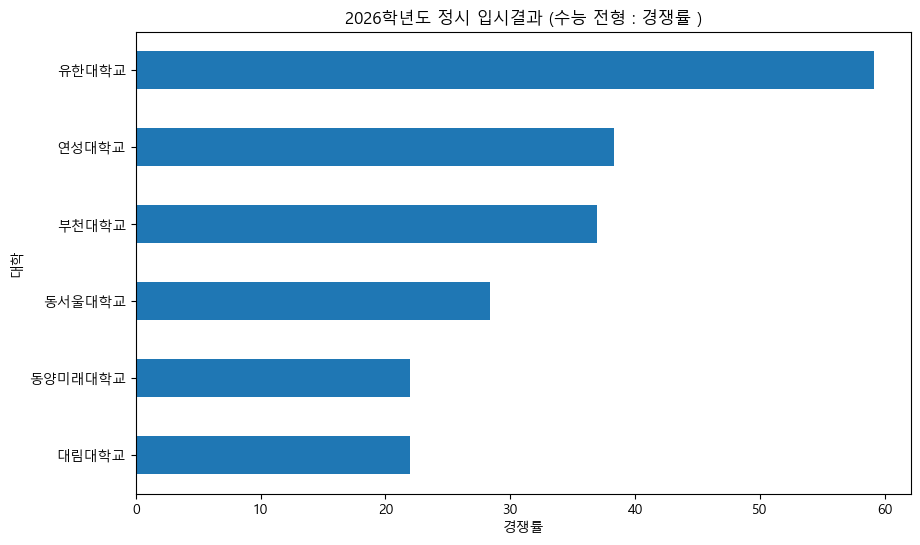

In [29]:
## 데이터프레임으로 막대 그래프 그리기 : 대학별 합계 경쟁률
# 데이터프레임을 정렬하고, index를 컬럼으로 전환
import seaborn as sns
import matplotlib.pyplot as plt

df_sorted = df_tot.sort_values('경쟁률').reset_index()
plt.rc('font', family='Malgun Gothic')
df_sorted.plot(kind='barh', x='대학', y='경쟁률',
               title='2026학년도 정시 입시결과 (수능 전형 : 경쟁률 )',
               xlabel='경쟁률', ylabel='대학',
               figsize=(10, 6), legend=False)

#### **7-2. [대학 전체] 대학별 총 지원자 수 비교 그래프 그리기**
> 대학별 합계 지원자 수 순위 막대 그래프 그리기\
> 총지원인원 순으로 그리기

<Axes: title={'center': '2026학년도 정시 입시결과 (수능 전형 : 총지원자 수 )'}, xlabel='총지원인원', ylabel='대학'>

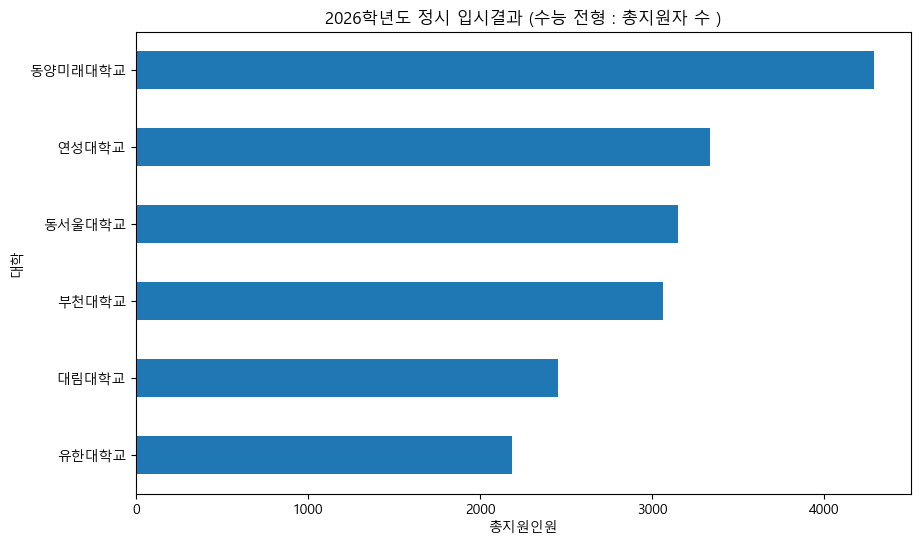

In [ ]:
## 데이터프레임으로 막대 그래프 그리기 : 대학별 총 지원자 수
# 데이터프레임을 정렬하고, index를 컬럼으로 전환
df_sorted2 = df_tot.sort_values('총지원인원').reset_index()

# 데이터프레임으로 막대 그래프 그리기
df_sorted2.plot(kind='barh', x='대학', y='총지원인원',
                title='2026학년도 정시 입시결과 (수능 전형 : 총지원자 수 )',
                xlabel='총지원인원', ylabel='대학',
                figsize=(10, 6), legend=False)


#### **8. [분석-상하위학과] 대학별 경쟁률 상위 3, 하위 3개 학과 정보 추출하기: df_top3, df_bottom3**
##### 8-1. 각 대학별로 경쟁률 상위 3개 모집단위(학과)명, 경쟁률을 순서대로 출력하시오.

In [31]:
df_top3 = df_all.groupby('대학', group_keys=False, sort=False).apply(lambda x: x.nlargest(3, '경쟁률'))

df_top3

,대학,모집단위,모집인원,지원인원,경쟁률
18,동양미래대학교,경영학과,7,233,33.29
20,동양미래대학교,유통마케팅학과,7,223,31.86
21,동양미래대학교,호텔관광학과,8,220,27.50
18,동서울대학교,세무회계과,1,131,131.00
9,동서울대학교,산업디자인학과,1,98,98.00
16,동서울대학교,보건의료행정과,1,97,97.00
14,대림대학교,경영학과,1,88,88.00
24,대림대학교,치위생과,1,85,85.00
25,대림대학교,응급구조과,1,61,61.00
21,연성대학교,유아교육과,1,101,101.00


##### 8-2. 각 대학별로 경쟁률 하위 3개 모집단위(학과)명, 경쟁률을 순서대로 출력하시오.

In [32]:
df_bottom3 = df_all.groupby('대학', group_keys=False, sort=False).apply(lambda x: x.nsmallest(3, '경쟁률'))

df_bottom3

,대학,모집단위,모집인원,지원인원,경쟁률
8,동양미래대학교,웹응용소프트웨어공학과,7,91,13.00
6,동양미래대학교,정보통신공학과,10,159,15.90
16,동양미래대학교,AR·VR콘텐츠디자인과,8,132,16.50
21,동서울대학교,글로벌중국비즈니스과,5,70,14.00
7,동서울대학교,컴퓨터소프트웨어학과,21,297,14.14
8,동서울대학교,건축학과,21,298,14.19
16,대림대학교,사무행정학과,21,242,11.52
1,대림대학교,건설환경공학과,9,108,12.00
5,대림대학교,모바일앱전공 AI융합소프트웨어전공,20,247,12.35
11,연성대학교,웹툰만화콘텐츠과,10,126,12.60


##### 8-3. 각 대학별로 경쟁률 하위 3개 모집단위(학과)에 대한 막대그래프로 그리기

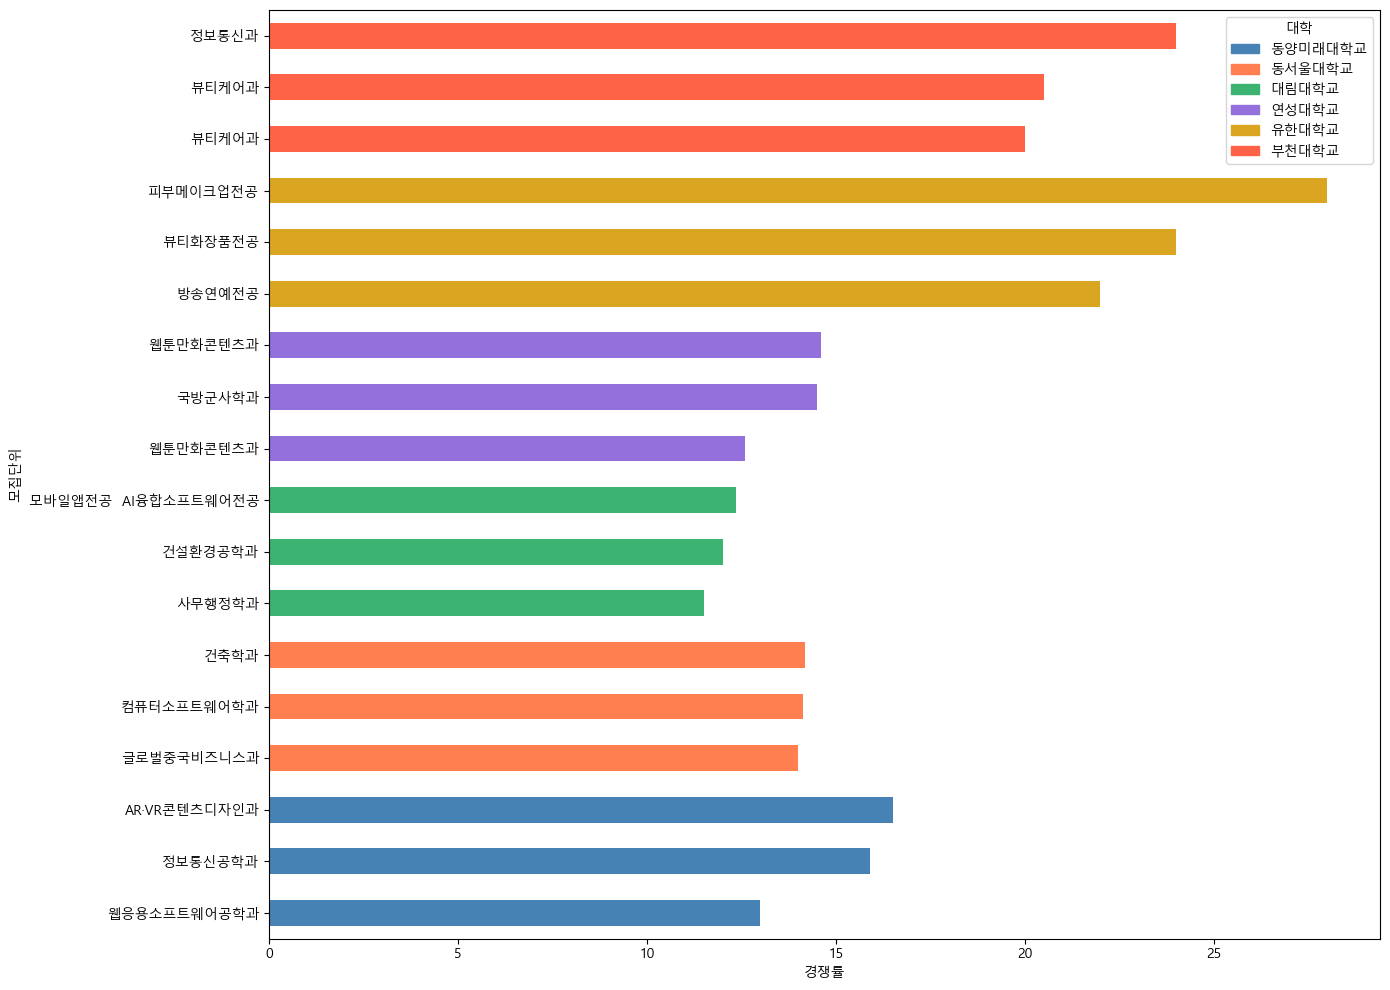

In [33]:
## 막대 그래프 만들기
import matplotlib.patches as mpatches

univ_list = df_bottom3['대학'].unique()
palette = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'goldenrod', 'tomato']
color_map = {u: palette[i] for i, u in enumerate(univ_list)}
colors = df_bottom3['대학'].map(color_map)

ax = df_bottom3.plot(kind='barh', x='모집단위', y='경쟁률',
                     xlabel='경쟁률', ylabel='모집단위',
                     figsize=(14, 10), legend=False,
                     color=colors.values)

patches = [mpatches.Patch(color=color_map[u], label=u) for u in univ_list]
ax.legend(handles=patches, title='대학')
plt.tight_layout()
plt.show()

#### **9. [분석-SW관련학과] 비교 대상 소프트웨어 관련 학과만 데이터 추출하여 데이터 프레임 구축하기: df_sw**
> 주요 대학 (SW 관련 학과명) : 부천대학교(컴퓨터소프트웨어과), 유한대학교(컴퓨터소프트웨어전공),\
> 연성대학교(컴퓨터소프트웨어과), 대림대학교(소프트웨어학부), 동서울대학교(컴퓨터소프트웨어학과),\
> 동양미래대학교(컴퓨터소프트웨어공학과)
##### 대학명, 비교할 대학의 학과명 만으로 데이터 프레임 구성
##### 컬럼은 ['대학', '모집단위', '모집인원', '지원인원', '경쟁률']로 구성

##### **소프트웨어 관련 학과 행만 추출하여 데이터 프레임 구축하기**
> 초기에 구축한 대학별 페이지 데이터 프레임의 'university', 'deptname' 데이터 활용

##### **[행 추출] SW 관련 대표 학과만 추출**
> 대학별 페이지 데이터 프레임의 'university', 'deptname'만으로 데이터 프레임을 구축하여 .merge() 적용

In [34]:
#### 9-1. 비교 대상 소프트웨어 관련 학과만 데이터 추출하여 데이터 프레임 구성
df_sw_key = df_url[['university', 'deptname']].rename(columns={'university': '대학', 'deptname': '모집단위'})
df_sw = df_sw_key.merge(df_all, on=['대학', '모집단위']).reset_index(drop=True)
df_sw = df_sw[['대학', '모집단위', '모집인원', '지원인원', '경쟁률']]

df_sw

,대학,모집단위,모집인원,지원인원,경쟁률
0,부천대학교,컴퓨터소프트웨어과,6,183,30.50
1,유한대학교,컴퓨터소프트웨어전공,1,74,74.00
2,연성대학교,컴퓨터소프트웨어과,5,140,28.00
3,동서울대학교,컴퓨터소프트웨어학과,21,297,14.14
4,동양미래대학교,컴퓨터소프트웨어공학과,8,168,21.00


#### **10-1. [분석-SW관련학과] 대학별 SW 관련 학과와 경쟁률 비교 그래프 그리기**
> 대학별 SW 관련 학과 경쟁률 순위 막대 그래프 그리기\
> 경쟁률이 높은 순으로 보기

<Axes: title={'center': '2026학년도 정시 입시결과 (SW 관련 학과 : 경쟁률 )'}, xlabel='경쟁률', ylabel='대학'>

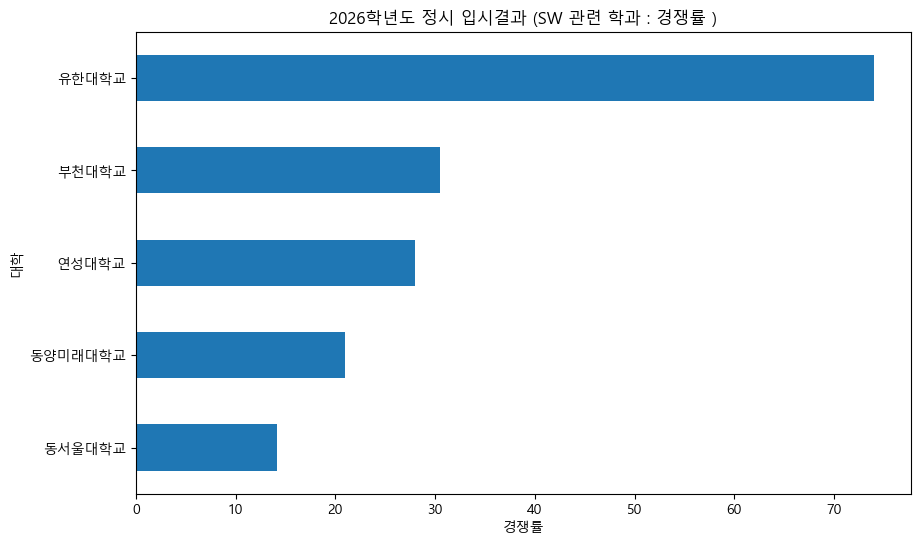

In [35]:
## 데이터프레임으로 막대 그래프 그리기 : 경쟁률
# 데이터프레임을 경쟁률이 높은 순으로 정렬
df_sw_sort1 = df_sw.sort_values('경쟁률')

# 데이터프레임으로 막대 그래프 그리기
df_sw_sort1.plot(kind='barh', x='대학', y='경쟁률',
                 title='2026학년도 정시 입시결과 (SW 관련 학과 : 경쟁률 )',
                 xlabel='경쟁률', ylabel='대학',
                 figsize=(10, 6), legend=False)

#### **10-2. [분석-SW관련학과] 대학별 SW 관련 학과와 지원자 수 비교 그래프 그리기**
> 대학별 SW 관련 학과 총 지원자 수 순위 막대 그래프 그리기
>> 총 지원자 수가 많은 순으로 보기

<Axes: title={'center': '2026학년도 정시 입시결과 (SW 관련 학과 : 총지원자 수 )'}, xlabel='지원인원', ylabel='대학'>

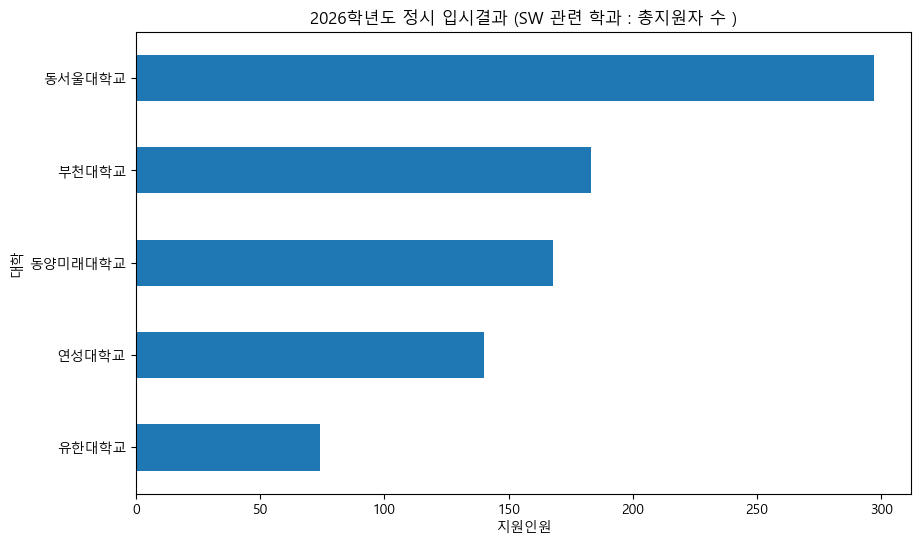

In [36]:
## 데이터프레임으로 막대 그래프 그리기 : 지원자 수
# 데이터프레임을 지원인원이 높은 순으로 정렬
df_sw_sort2 = df_sw.sort_values('지원인원')

# 데이터프레임으로 막대 그래프 그리기
df_sw_sort2.plot(kind='barh', x='대학', y='지원인원',
                 title='2026학년도 정시 입시결과 (SW 관련 학과 : 총지원자 수 )',
                 xlabel='지원인원', ylabel='대학',
                 figsize=(10, 6), legend=False)

----

### **[제출] 문제에 대한 해결을 완성한데까지의 .ipynb 파일을 LMS의 제출란에 첨부하여 제출하기 바랍니다.**
#### > 제출하는 파일의 이름에는 반드시 학번이나 이름을 포함시키세요.
> 예를 들어 'End_Test_123456.ipynb' 형태로 제출 (파일명의 ID 대신에 학번이나 이름을 사용)